In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
### Radar system parameters
c=3e8 #speed of light (m/s)
t_s=10*1e-9 #sampling time:10 ns
f_s=1/t_s #sampling frequency: 100 MHz
N=256 #number of samples per pulse
N_fft=2*N #FFT size:512
t_pri=N*t_s #pulse repetition interval: 2.5 us
N_pw=52 #20% duty cycle
time_axis=np.arange(0,t_pri,t_s) #time axis (seconds)
range_axis=c*time_axis/2 #range axis (meters)

Text(0, 0.5, 'Amplitude')

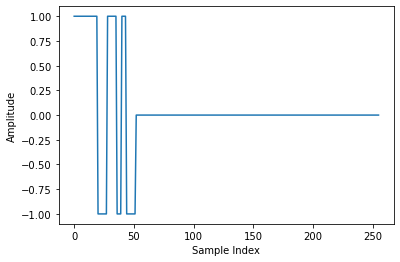

In [3]:
### Generate transmit signal
radar_seq=np.loadtxt('tx_sequence.txt')  #Load radar sequence
tx_signal=np.zeros(N)
tx_signal[0:N_pw]=radar_seq
plt.plot(tx_signal)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

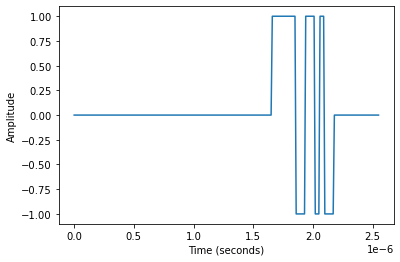

In [4]:
### Target parameters
target_range=250 # target range in meters
delay_idx=int(2*target_range/c/t_s) #calculate delay index
amplitude=1 # target amplitude

### Generate received signal
rx_signal=np.zeros(N_fft)
rx_signal[delay_idx:delay_idx+N_pw]=radar_seq*amplitude

### Plot received signal
plt.plot(time_axis,rx_signal[:N])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

## **PS Execution**

In [5]:
### Range Estimation at Receiver through Matched Filtering
ps_start=time.time()
fft_tx=np.conjugate(np.fft.fft(tx_signal,N_fft)) #(FFT+conjugate) of the transmitted sequence
fft_rx=np.fft.fft(rx_signal,N_fft)#FFT of the received sequence
mul=fft_tx*fft_rx #multiplication
mf_sw=np.fft.ifft(mul,N_fft) #IFFT 
ps_end=time.time()

In [6]:
# PS time for range estimation (seconds)
ps_time=ps_end-ps_start
ps_time

0.006710052490234375

Estimated target range (meters):  249.0


Text(0, 0.5, 'Amplitude')

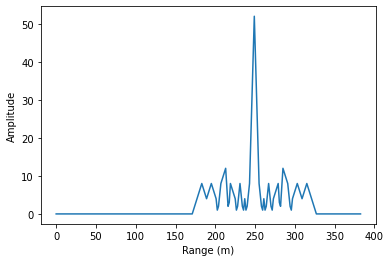

In [7]:
# Peak Search and plotting PS matched filter output
mf_fftshift_sw=np.fft.fftshift(mf_sw) 
mf_mag_sw=np.abs(mf_fftshift_sw[N:N_fft]) #magnitude of spectrum
idx=np.argmax(mf_mag_sw) #peak search
print("Estimated target range (meters): ", range_axis[idx])
plt.plot(range_axis,mf_mag_sw)
plt.xlabel("Range (m)")
plt.ylabel("Amplitude")

## **PL Execution**

In [8]:
from pynq import Overlay
from pynq import allocate
ol = Overlay("radar.bit")# Download Overlay
### create DMA instances
dma=ol.axi_dma_0
dma_send=dma.sendchannel
dma_recv=dma.recvchannel

In [9]:
ol?

In [10]:
### create input and output pynq buffers for DMA transfers
input_buffer = allocate(shape=(N_fft,), dtype=np.complex64)
output_buffer = allocate(shape=(N_fft,), dtype=np.complex64)
np.copyto(input_buffer,rx_signal)

In [11]:
### DMA transfers for range estimation in PL matrix
pl_start=time.time()
dma_send.transfer(input_buffer)
dma_recv.transfer(output_buffer)
dma_send.wait()
dma_recv.wait()
pl_end=time.time()

In [12]:
# PL time for range estimation (seconds)
pl_time=pl_end-pl_start
pl_time

0.003642559051513672

In [13]:
# Calculate the acceleration factor
AF=ps_time/pl_time
AF

1.842125932713706

Estimated target range (meters):  249.0


Text(0, 0.5, 'Amplitude')

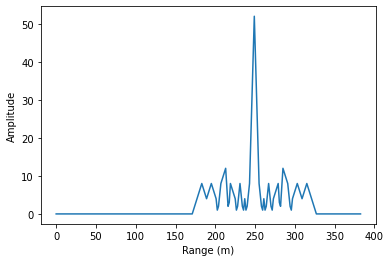

In [14]:
# Peak Search and plotting PL matched filter output
mf_hw=np.zeros((N_fft,),dtype=np.complex64)
np.copyto(mf_hw,output_buffer/512)#SCALE by 512 after IFFT operation
mf_fftshift_hw=np.fft.fftshift(mf_hw)
mf_mag_hw=np.abs(mf_fftshift_hw[N:N_fft]) #magnitude of spectrum
idx=np.argmax(mf_mag_hw) #peak search
print("Estimated target range (meters): ", range_axis[idx])
plt.plot(range_axis,mf_mag_hw)
plt.xlabel("Range (m)")
plt.ylabel("Amplitude")

In [15]:
# RMSE between PS and PL outputs
rmse=np.sqrt(np.sum(np.square(np.abs(mf_sw-mf_hw)))/N_fft)
rmse

1.2215317208705614e-06